In [57]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy.signal as signal

## 1

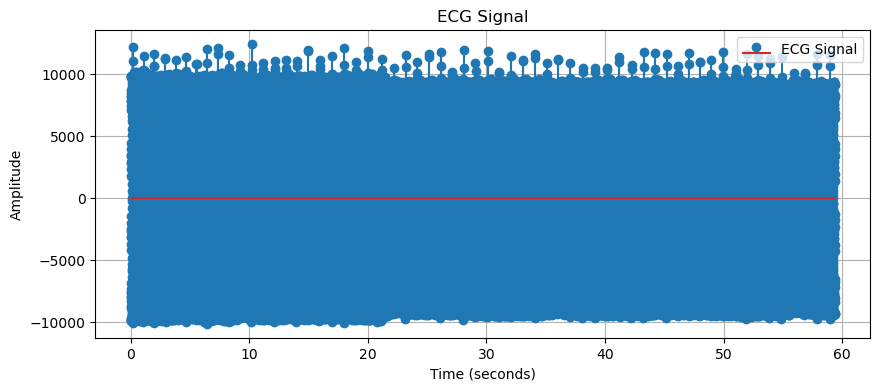

In [58]:
# Load ECG data
data = np.loadtxt("ecg.dat", delimiter=",")  # Adjust delimiter if needed

# Define sampling rate and time vector
fs = 500  # Hz
t = np.arange(0, len(data) / fs, 1 / fs)  # Create time array

# Plot ECG signal
plt.figure(figsize=(10, 4))
plt.stem(t, data, label="ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal")
plt.legend()
plt.grid(True)
plt.show()


## 2

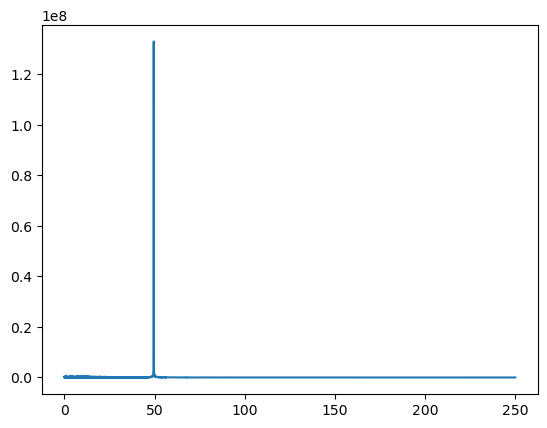

In [59]:
data_fft = np.fft.fft(data) # Compute the Fourier Transform of the data
f = np.fft.fftfreq(len(data), 1/fs) # Frequency vector
plt.plot(f[:len(f)//2], np.abs(data_fft)[:len(data_fft)//2]) # plot only the positive frequencies

## 3

We set $b_{0}=1$ for a simple filter. Thereafter the given equation can be used. The input frequency $\phi$ frequency can be calculated from as $\phi = \frac{2 \pi f_0}{f_s}$. This gives all the zeros of filter, which has no poles.

## 4

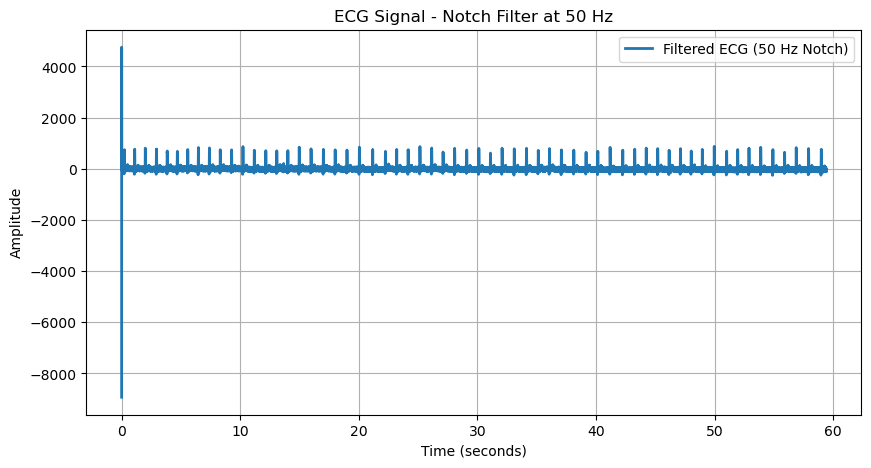

In [60]:
# Given parameters
fs = 500  # Sampling frequency (Hz)
f0 = 50   # Frequency to remove (Hz)
phi = (2 * np.pi * f0) / fs  # Compute phi

# Compute filter coefficients
b = [1, -2 * np.cos(phi), 1]  # Numerator coefficients
a = [1]  # Denominator coefficients (FIR filter)

# Load the ECG data
data = np.loadtxt("ecg.dat", delimiter=",")  # Adjust delimiter if needed

# Apply the filter using lfilter
filtered_ecg = signal.lfilter(b, a, data)

# Create time axis
t = np.arange(0, len(data) / fs, 1 / fs)

# Plot original and filtered ECG
plt.figure(figsize=(10, 5))
plt.plot(t, filtered_ecg, label="Filtered ECG (50 Hz Notch)", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal - Notch Filter at 50 Hz")
plt.legend()
plt.grid(True)
plt.show()


## 5

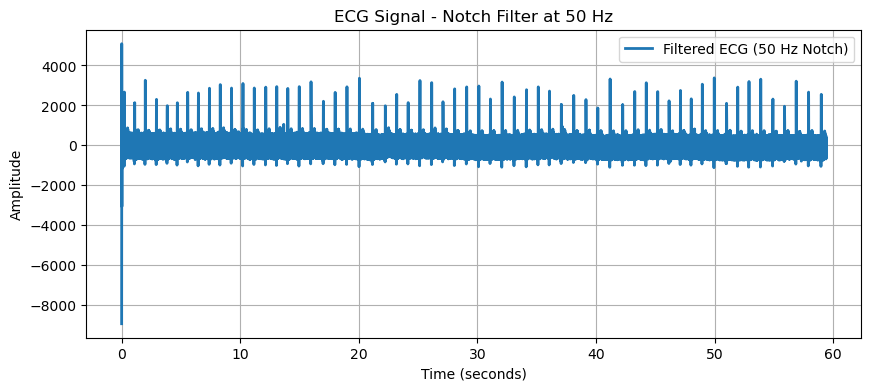

In [61]:
# Compute filter coefficients
r = 0.9  # Pole radius
b = [1, -2 * np.cos(phi), 1]  # Numerator coefficients
a = [1, -2 * r * np.cos(phi), r**2]  # Denominator coefficients (FIR filter)

# Apply the filter using lfilter
filtered_ecg = signal.lfilter(b, a, data)

# Create time axis
t = np.arange(0, len(data) / fs, 1 / fs)

# Plot original and filtered ECG
plt.figure(figsize=(10, 4))
plt.plot(t, filtered_ecg, label="Filtered ECG (50 Hz Notch)", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal - Notch Filter at 50 Hz")
plt.legend()
plt.grid(True)
plt.show()


## 6

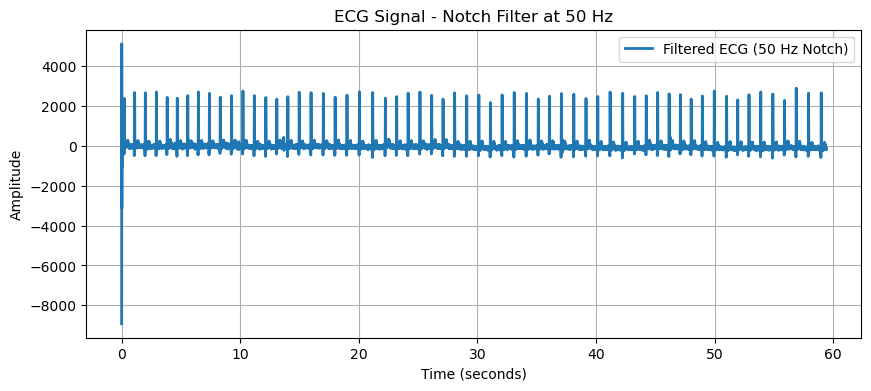

In [62]:
# Compute filter coefficients
f0 = 49.5   # Frequency to remove (Hz)
phi = (2 * np.pi * f0) / fs  # Compute phi
b = [1, -2 * np.cos(phi), 1]  # Numerator coefficients
a = [1, -2 * r * np.cos(phi), r**2]  # Denominator coefficients (FIR filter)

# Apply the filter using lfilter
filtered_ecg = signal.lfilter(b, a, data)

# Create time axis
t = np.arange(0, len(data) / fs, 1 / fs)

# Plot original and filtered ECG
plt.figure(figsize=(10, 4))
plt.plot(t, filtered_ecg, label="Filtered ECG (50 Hz Notch)", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal - Notch Filter at 50 Hz")
plt.legend()
plt.grid(True)
plt.show()


It be better.